# TX Crash


In [1]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\annza\anaconda3\python.exe
3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]


In [3]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
#These libraries let us process millions of crash rows, map them spatially, and find the nearest traffic station efficiently
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from tqdm.auto import tqdm
tqdm.pandas()

import geopandas as gpd # for map locations to zip codes
from shapely.geometry import Point
from sklearn.neighbors import BallTree # for fast spatial joins (mapping lat/lon to zip code polygons)

In [4]:
# ── 0) FILE PATHS ────────────────────────────────────────────────────────────

# Station source — historical AADT records
STATIONS_PATH = r"old_aadt.csv"

# Consolidated crash file — all years 2015-2024 in one file
MASTER_CRASH_PATH = r"master_data_2015-2024.csv"

# Texas ZIP code polygons for spatial join
ZIP_GEOJSON_PATH = r"tx_texas_zip_codes_geo.min.json"

# Output directory — one Cleaned_Data_[YEAR].csv will be written here
OUT_DIR = r"outputs/"

# Years to process
CRASH_YEARS = list(range(2015, 2025))  # 2015 through 2024

In [30]:
df_check = pd.read_csv(
    MASTER_CRASH_PATH,
    skiprows=4,
    usecols=["Crash_Date", "Crash_ID"],
    low_memory=False
)

# convert to datetime
df_check["Crash_Date"] = pd.to_datetime(
    df_check["Crash_Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

# extract year
df_check["Crash_Year"] = df_check["Crash_Date"].dt.year

# count years
print(df_check["Crash_Year"].value_counts(dropna=False).sort_index())

Crash_Year
2016    1097926
2017     537497
2018     544176
2019     561412
2020     472050
2021     547288
2022     551766
2023     420714
2024     549428
Name: count, dtype: int64


In [31]:
dup_count = df_check.loc[df_check["Crash_Year"] == 2016, "Crash_ID"].duplicated().sum()
print(dup_count)

548963


In [32]:
#check 2015 count
print("2015 rows:", (df_check["Crash_Year"] == 2015).sum())

2015 rows: 0


In [33]:
# Reload raw file directly
raw_check = pd.read_csv(STATIONS_PATH, low_memory=False)

# Clean columns
raw_check.columns = raw_check.columns.astype(str).str.strip()

print("Shape:", raw_check.shape)

print("\nUnique years:")
print(raw_check["LATEST_AADT_YR"].value_counts(dropna=False).sort_index())

print("\nNumber of unique station IDs:")
print(raw_check["TRFC_STATN_ID"].nunique())

print("\nRecords per station:")
print(raw_check.groupby("TRFC_STATN_ID").size().describe())

print("\nStations with >1 records:")
multi = raw_check.groupby("TRFC_STATN_ID").size()
print((multi > 1).sum())

Shape: (100488, 40)

Unique years:
LATEST_AADT_YR
2004        6
2005        2
2006        2
2007        1
2009       24
2010       13
2011       19
2012      237
2013        8
2014      885
2015     1033
2016     1842
2017       28
2018      119
2019     8434
2020    12216
2021     3565
2022    23505
2023    48549
Name: count, dtype: int64

Number of unique station IDs:
100488

Records per station:
count    100488.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
dtype: float64

Stations with >1 records:
0


We set 3 important rules according to AADT ENRICHMENT sheet:
1. Maximum matching distance = 1 mile

"Only assign a traffic station to a crash if the station is within 1 mile. If nothing is within 1 mile, leave it blank."

2. Earth radius = 3958.8 miles

Used to convert math distances into real miles.

3. Texas bounding box

Any crash GPS coordinate outside Texas (latitude 25.8–36.5, longitude -106.6 to -93.5) gets removed as bad/junk data.

In [34]:
# ── 1) SETTINGS ──────────────────────────────────────────────────────────────

# Maximum crash-to-station distance allowed (miles)
# Matches > this are nulled out — same rule as Arizona
MAX_STATION_MILES = 1.0

# Earth radius for haversine → miles conversion
EARTH_RADIUS_MILES = 3958.8

# Texas geographic bounding box 
# Anything outside this box is dropped as junk / out-of-state coordinates
TX_LAT_MIN, TX_LAT_MAX =  25.8,  36.5
TX_LON_MIN, TX_LON_MAX = -106.6, -93.5

# We built a table of how much total driving happened in Texas each year:
# Why this matters: Traffic station counts are from different years. 
# This dictionary lets us adjust old counts to match the crash year. 
# For example, a station that counted 10,000 cars/day in 2016 would be adjusted upward for a 2023 crash because Texas roads were busier in 2023.
TX_VMT_MILLIONS = {
    2015: 258300,
    2016: 270700,
    2017: 273200,
    2018: 282200,
    2019: 288400,
    2020: 260000,   
    2021: 285200,   
    2022: 291100,
    2023: 301500,
    2024: 307800,
    2025: 307800,
}

In [35]:
# ── 2) HELPER FUNCTIONS ───────────────────────────────────────────────────────
# Copied directly from Arizona notebook — no changes needed

def clean_colnames(df: pd.DataFrame) -> pd.DataFrame:
    """Strip whitespace from column names."""
    df.columns = df.columns.astype(str).str.strip()
    return df

def to_num(s):
    """Coerce a Series to numeric, turning bad values into NaN."""
    return pd.to_numeric(s, errors="coerce")

def compute_vmt_multiplier(station_year, crash_year):
    """
    Compute VMT normalization multiplier for Texas.
    Returns: (vmt_station, vmt_crash, multiplier)

    Formula (same as Arizona):
        multiplier = TX_VMT(crash_year) / TX_VMT(station_year)
        Adt_Curnt_Amt = Station_Count * multiplier
    """
    if pd.isna(station_year) or pd.isna(crash_year):
        return (np.nan, np.nan, np.nan)

    station_year = int(station_year)
    crash_year   = int(crash_year)

    vmt_station = TX_VMT_MILLIONS.get(station_year, np.nan)
    vmt_crash   = TX_VMT_MILLIONS.get(crash_year,   np.nan)

    if pd.isna(vmt_station) or pd.isna(vmt_crash) or vmt_station == 0:
        return (vmt_station, vmt_crash, np.nan)

    return (vmt_station, vmt_crash, vmt_crash / vmt_station)

In [36]:
# ── ACTION 02: Load & Clean the Traffic Station Dataset ───────────────────────────────
# Source file : old_aadt.csv
# Key columns : AADT_RPT_QTY  (= LastCount_Daily in Arizona)
#               AADT_RPT_YEAR (= LastCountYear  in Arizona)
#               Station ID    (confirm exact column name after loading)

stations = pd.read_csv(STATIONS_PATH, low_memory=False)
stations = clean_colnames(stations)

print("Columns in old_aadt.csv:")
print(stations.columns.tolist())
print("\nShape:", stations.shape)
print("\nFirst 3 rows:")
stations.head(3)

Columns in old_aadt.csv:
['DIST_NBR', 'DIST_NM', 'CNTY_NBR', 'CNTY_NM', 'TRFC_STATN_ID', 'CATEGORY', 'ACTIVE', 'LATEST_AADT_YR', 'LATEST_AADT_QTY', 'AADT_RPT_YEAR', 'AADT_RPT_QTY', 'AADT_RPT_HIST_01_QTY', 'AADT_RPT_HIST_02_QTY', 'AADT_RPT_HIST_03_QTY', 'AADT_RPT_HIST_04_QTY', 'AADT_RPT_HIST_05_QTY', 'AADT_RPT_HIST_06_QTY', 'AADT_RPT_HIST_07_QTY', 'AADT_RPT_HIST_08_QTY', 'AADT_RPT_HIST_09_QTY', 'AADT_RPT_HIST_10_QTY', 'AADT_RPT_HIST_11_QTY', 'AADT_RPT_HIST_12_QTY', 'AADT_RPT_HIST_13_QTY', 'AADT_RPT_HIST_14_QTY', 'AADT_RPT_HIST_15_QTY', 'AADT_RPT_HIST_16_QTY', 'AADT_RPT_HIST_17_QTY', 'AADT_RPT_HIST_18_QTY', 'AADT_RPT_HIST_19_QTY', 'ZLEVEL', 'ON_ROAD', 'IN_GRID', 'COUNT_CYCLE', 'LATITUDE', 'LONGITUDE', 'OBJECTID', 'x', 'y', 'ZIP_Code']

Shape: (100488, 40)

First 3 rows:


,DIST_NBR,DIST_NM,CNTY_NBR,CNTY_NM,TRFC_STATN_ID,CATEGORY,ACTIVE,LATEST_AADT_YR,LATEST_AADT_QTY,AADT_RPT_YEAR,...,ZLEVEL,ON_ROAD,IN_GRID,COUNT_CYCLE,LATITUDE,LONGITUDE,OBJECTID,x,y,ZIP_Code
0,25,Childress,100,Hardeman,100CR1,URBAN ACR,1,2022,35,2023,...,13,RINE RD,1,5,34.329484,-99.733451,476056,-11102276.98,4073129.947,79252.0
1,25,Childress,100,Hardeman,100CR12,URBAN ACR,1,2022,7,2023,...,13,KINGS HIGH RD,1,5,34.283909,-99.661497,476057,-11094267.10,4066988.075,79252.0
2,25,Childress,100,Hardeman,100CR13,URBAN ACR,1,2022,7,2023,...,13,HAMBY,1,5,34.289844,-99.683707,476058,-11096739.50,4067787.711,79252.0


In [37]:
# ── ACTION 02 (continued): Column Mapping ─────────────────────────────────────
LAT_COL   = "LATITUDE"
LON_COL   = "LONGITUDE"
LOC_COL   = "TRFC_STATN_ID"
COUNT_COL = "LATEST_AADT_QTY"
YEAR_COL  = "LATEST_AADT_YR"

# Validate all required columns exist
required_station_cols = [LAT_COL, LON_COL, LOC_COL, COUNT_COL, YEAR_COL]
missing_cols = [c for c in required_station_cols if c not in stations.columns]
if missing_cols:
    raise ValueError(f"❌ Missing columns: {missing_cols}")
else:
    print("✅ All required columns found!")

# Convert to numeric
stations[LAT_COL]   = to_num(stations[LAT_COL])
stations[LON_COL]   = to_num(stations[LON_COL])
stations[COUNT_COL] = to_num(stations[COUNT_COL])
stations[YEAR_COL]  = to_num(stations[YEAR_COL]).astype("Int64")
stations[LOC_COL]   = stations[LOC_COL].astype(str).str.strip()

# Drop rows with null lat/lon or null/zero AADT count
before = len(stations)
stations = stations.dropna(subset=[LAT_COL, LON_COL, COUNT_COL]).copy()
stations = stations[stations[COUNT_COL] > 0].copy()
print(f"After dropping nulls/zeros: {len(stations):,}  (removed {before - len(stations):,})")

# Rename to standard internal names
stations["Station_Count"] = stations[COUNT_COL]
stations["Station_Year"]  = stations[YEAR_COL]

# Keep all station-year records for VMT/year-gap logic
stations_all_years = stations.copy()

print(f"✅ Total station-year records: {len(stations_all_years):,}")
print(f"✅ Unique station IDs: {stations_all_years[LOC_COL].nunique():,}")

# Build spatial matching table using one location per station ID
stations_locations = (
    stations_all_years
    .sort_values("Station_Year")
    .groupby(LOC_COL, as_index=False)
    .tail(1)
    .copy()
)

# print(f"Unique stations after dedup: {stations[LOC_COL].nunique():,}")
print(f"✅ Unique station locations for BallTree: {stations_locations[LOC_COL].nunique():,}")

✅ All required columns found!
After dropping nulls/zeros: 100,400  (removed 88)
✅ Total station-year records: 100,400
✅ Unique station IDs: 100,400
✅ Unique station locations for BallTree: 100,400


In [38]:
# ── ACTION 03: Build BallTree on Station Coordinates ─────────────────────────
# This replaces the slow manual haversine loop that caused 24+ min runtimes.
# BallTree with haversine metric runs in seconds even for 500k+ crash records.

stations_coords_rad = np.radians(stations_locations[[LAT_COL, LON_COL]].values)
tree = BallTree(stations_coords_rad, metric="haversine")

print("✅ Station-year records:", len(stations_all_years))

print("✅ BallTree built on", len(stations_locations), "Texas traffic stations")

✅ Station-year records: 100400
✅ BallTree built on 100400 Texas traffic stations


In [39]:
# ── Load master crash file ────────────────────────────────────────────────────
os.makedirs(OUT_DIR, exist_ok=True)

print("Loading master crash file...")
master_df = pd.read_csv(MASTER_CRASH_PATH, low_memory=False, on_bad_lines='skip', skiprows=4)
master_df = clean_colnames(master_df)
master_df = master_df.drop_duplicates()
print(f"✅ Master file loaded: {len(master_df):,} rows")

# Extract Crash_Year from Crash_Date column (format: MM/DD/YYYY)
YEAR_CRASH_COL = "Crash_Year"
master_df["Crash_Year"] = pd.to_datetime(
    master_df["Crash_Date"], format="%m/%d/%Y", errors="coerce"
).dt.year
print(f"Years in master file: {sorted(master_df['Crash_Year'].dropna().unique().astype(int).tolist())}")
print(f"Rows per year:\n{master_df['Crash_Year'].value_counts().sort_index()}")

# ── Load ZIP boundaries ONCE before the loop ─────────────────────────────────
print("\nLoading ZIP code boundaries...")
zip_gdf = gpd.read_file(ZIP_GEOJSON_PATH)

zip_gdf = clean_colnames(zip_gdf)
if "ZCTA5CE10" not in zip_gdf.columns:
    raise ValueError("ZIP GeoJSON must contain a ZCTA5CE10 column.")
print(f"✅ ZIP boundaries loaded: {len(zip_gdf):,} ZIP polygons")

# ── Process each year ─────────────────────────────────────────────────────────
all_outputs = []

for crash_year in CRASH_YEARS:
    print(f"\n{'='*50}")
    print(f"Processing TX Crash Year: {crash_year}")
    print(f"{'='*50}")

    # Filter master file to this year
    df = master_df[master_df[YEAR_CRASH_COL] == crash_year].copy()

    if len(df) == 0:
        print(f"  ⚠️  No rows for {crash_year} — skipping.")
        continue

    print(f"  Rows for {crash_year}: {len(df):,}")

    df["Latitude"]   = to_num(df["Latitude"])
    df["Longitude"]  = to_num(df["Longitude"])
    df["Crash_Year"] = crash_year

    # ACTION 06 — Coordinate bounds filter
    before_bounds = len(df)
    df = df.dropna(subset=["Latitude", "Longitude"]).copy()
    df = df[
        df["Latitude"].between(TX_LAT_MIN, TX_LAT_MAX) &
        df["Longitude"].between(TX_LON_MIN, TX_LON_MAX)
    ].copy()
    print(f"  After coord filter: {len(df):,}  (removed {before_bounds - len(df):,})")

    # ACTION 04 — Spatial match via BallTree
    df["Nearest_Station_LocationId"] = pd.NA
    df["Station_Lat"]                = np.nan
    df["Station_Lon"]                = np.nan
    df["Station_Count"]              = np.nan
    df["Station_Year"]               = pd.NA
    df["Distance_Miles"]             = np.nan
    df["VMT_Station"]                = np.nan
    df["VMT_Crash"]                  = np.nan
    df["VMT_Multiplier"]             = np.nan

    has_xy = df["Latitude"].notna() & df["Longitude"].notna()

    if has_xy.sum() > 0:
        crash_coords_rad = np.radians(df.loc[has_xy, ["Latitude", "Longitude"]].values)
        distances_rad, indices = tree.query(crash_coords_rad, k=1)
        distances_miles = distances_rad.flatten() * EARTH_RADIUS_MILES
        idx = indices.flatten()
        # matched = stations.iloc[idx].reset_index(drop=True)
        matched = stations_locations.iloc[idx].reset_index(drop=True)

        df.loc[has_xy, "Nearest_Station_LocationId"] = matched[LOC_COL].astype(str).values
        df.loc[has_xy, "Station_Lat"]                = matched[LAT_COL].values
        df.loc[has_xy, "Station_Lon"]                = matched[LON_COL].values
        df.loc[has_xy, "Distance_Miles"]             = distances_miles

        # Null out matches > 1 mile (quality control)
        far_mask = df["Distance_Miles"].notna() & (df["Distance_Miles"] > MAX_STATION_MILES)
        df.loc[far_mask, [
            "Nearest_Station_LocationId", "Station_Lat", "Station_Lon",
            "Station_Count", "Station_Year"
        ]] = [pd.NA, np.nan, np.nan, np.nan, pd.NA]
        df.loc[far_mask, ["VMT_Station", "VMT_Crash", "VMT_Multiplier"]] = np.nan
        print(f"  Matches nulled (>{MAX_STATION_MILES} mile): {far_mask.sum():,}")

        # Choose best historical AADT count year for each matched crash
        df["_crash_row_id"] = df.index

        matched_hist = df[df["Nearest_Station_LocationId"].notna()].merge(
            stations_all_years[[LOC_COL, "Station_Count", "Station_Year"]],
            left_on="Nearest_Station_LocationId",
            right_on=LOC_COL,
            how="left",
            suffixes=("", "_hist")
        )

        matched_hist["year_gap_candidate"] = (
            matched_hist["Crash_Year"] - matched_hist["Station_Year_hist"]
        ).abs()

        best_hist = (
            matched_hist
            .sort_values(["_crash_row_id", "year_gap_candidate"])
            .groupby("_crash_row_id", as_index=False)
            .first()
        )

        df = df.merge(
            best_hist[["_crash_row_id", "Station_Count_hist", "Station_Year_hist", "year_gap_candidate"]],
            on="_crash_row_id",
            how="left"
        )

        df["Station_Count"] = df["Station_Count_hist"]
        df["Station_Year"] = df["Station_Year_hist"].astype("Int64")
        df["year_gap"] = df["year_gap_candidate"]

        df = df.drop(columns=[
            "_crash_row_id",
            "Station_Count_hist",
            "Station_Year_hist",
            "year_gap_candidate"
        ], errors="ignore")

    # Year gap
    df["Adt_Curnt_Year"] = df["Crash_Year"]
    # df["year_gap"] = np.where(
    #     df["Station_Year"].notna(),
    #     (df["Crash_Year"] - df["Station_Year"].astype("Int64")).abs(),
    #     np.nan
    # )

    # ACTION 05 — VMT normalization (vectorized — fast)
    df["VMT_Station"] = df["Station_Year"].map(TX_VMT_MILLIONS)
    df["VMT_Crash"]   = df["Crash_Year"].map(TX_VMT_MILLIONS)
    
    df["VMT_Multiplier"] = np.where(
        df["VMT_Station"].notna() & df["VMT_Crash"].notna() & (df["VMT_Station"] > 0),
        df["VMT_Crash"] / df["VMT_Station"],
        np.nan
    )

    df["Adt_Curnt_Amt"] = np.where(
        df["Station_Count"].notna() & df["VMT_Multiplier"].notna(),
        df["Station_Count"] * df["VMT_Multiplier"],
        np.nan
    )

    df["aadt_match_type"] = np.where(
        df["Adt_Curnt_Amt"].notna(),
        "NEAREST_STATION_VMT_NORM",
        "MISSING"
    )

    # ACTION 07 — ZIP spatial join (zip_gdf already loaded before loop)
    valid_rows = df.dropna(subset=["Latitude", "Longitude"]).copy()
    valid_rows["geometry"] = valid_rows.progress_apply(
        lambda r: Point(r["Longitude"], r["Latitude"]), axis=1
    )
    points_gdf = gpd.GeoDataFrame(valid_rows, geometry="geometry", crs="EPSG:4326")

    joined = gpd.sjoin(
        points_gdf,
        zip_gdf[["geometry", "ZCTA5CE10"]],
        how="left",
        predicate="within"
    )

    df["ZIP_Code"] = pd.NA
    df.loc[joined.index, "ZIP_Code"] = joined["ZCTA5CE10"].values
    df["ZIP_Code"] = pd.to_numeric(df["ZIP_Code"], errors="coerce").astype("Int64")
    print(f"  ZIP_Code missing before drop: {df['ZIP_Code'].isna().sum():,}")

    # Drop crashes outside any valid ZIP polygon
    before_zip = len(df)
    df = df.dropna(subset=["ZIP_Code"]).copy()
    print(f"  Dropped rows missing ZIP: {before_zip - len(df):,}")

    # Summary
    total   = len(df)
    filled  = int(df["Adt_Curnt_Amt"].notna().sum())
    missing = total - filled
    print(f"\n  Total crash rows : {total:,}")
    print(f"  AADT Filled      : {filled:,}  ({filled/total*100:.2f}%)")
    print(f"  AADT Missing     : {missing:,}  ({missing/total*100:.2f}%)")

    # ACTION 10 — Export
    out_path = os.path.join(OUT_DIR, f"Cleaned_Data_{crash_year}.csv")
    df.to_csv(out_path, index=False)
    print(f"  ✅ Saved → {out_path}")

    all_outputs.append(df)

df_final = all_outputs[-1]
print("\n✅ All years processed.")

Loading master crash file...
✅ Master file loaded: 4,733,294 rows
Years in master file: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Rows per year:
Crash_Year
2016    548963
2017    537497
2018    544176
2019    561412
2020    472050
2021    547288
2022    551766
2023    420714
2024    549428
Name: count, dtype: int64

Loading ZIP code boundaries...
✅ ZIP boundaries loaded: 1,939 ZIP polygons

Processing TX Crash Year: 2015
  ⚠️  No rows for 2015 — skipping.

Processing TX Crash Year: 2016
  Rows for 2016: 548,963
  After coord filter: 498,336  (removed 50,627)
  Matches nulled (>1.0 mile): 12,343


100%|███████████████████████████████████████████████████████████████████████| 498336/498336 [00:28<00:00, 17686.22it/s]


  ZIP_Code missing before drop: 1,147
  Dropped rows missing ZIP: 1,147

  Total crash rows : 497,189
  AADT Filled      : 478,562  (96.25%)
  AADT Missing     : 18,627  (3.75%)
  ✅ Saved → outputs/Cleaned_Data_2016.csv

Processing TX Crash Year: 2017
  Rows for 2017: 537,497
  After coord filter: 486,156  (removed 51,341)
  Matches nulled (>1.0 mile): 12,724


100%|███████████████████████████████████████████████████████████████████████| 486156/486156 [00:28<00:00, 16777.59it/s]


  ZIP_Code missing before drop: 1,331
  Dropped rows missing ZIP: 1,331

  Total crash rows : 484,825
  AADT Filled      : 466,324  (96.18%)
  AADT Missing     : 18,501  (3.82%)
  ✅ Saved → outputs/Cleaned_Data_2017.csv

Processing TX Crash Year: 2018
  Rows for 2018: 544,176
  After coord filter: 492,452  (removed 51,724)
  Matches nulled (>1.0 mile): 13,636


...

  ZIP_Code missing before drop: 1,303
  Dropped rows missing ZIP: 1,303

  Total crash rows : 496,021
  AADT Filled      : 477,165  (96.20%)
  AADT Missing     : 18,856  (3.80%)
  ✅ Saved → outputs/Cleaned_Data_2022.csv

Processing TX Crash Year: 2023
  Rows for 2023: 420,714
  After coord filter: 378,046  (removed 42,668)
  Matches nulled (>1.0 mile): 9,872


100%|███████████████████████████████████████████████████████████████████████| 378046/378046 [00:19<00:00, 18944.32it/s]


  ZIP_Code missing before drop: 939
  Dropped rows missing ZIP: 939

  Total crash rows : 377,107
  AADT Filled      : 362,885  (96.23%)
  AADT Missing     : 14,222  (3.77%)
  ✅ Saved → outputs/Cleaned_Data_2023.csv

Processing TX Crash Year: 2024
  Rows for 2024: 549,428
  After coord filter: 489,682  (removed 59,746)
  Matches nulled (>1.0 mile): 13,287


100%|███████████████████████████████████████████████████████████████████████| 489682/489682 [00:28<00:00, 17022.69it/s]


  ZIP_Code missing before drop: 1,203
  Dropped rows missing ZIP: 1,203

  Total crash rows : 488,479
  AADT Filled      : 469,788  (96.17%)
  AADT Missing     : 18,691  (3.83%)
  ✅ Saved → outputs/Cleaned_Data_2024.csv

✅ All years processed.


In [40]:
# ── ACTION 08: Missing AADT Diagnostics ───────────────────────────────────────
# Single year diagnostics for now — can expand to all years if needed

total        = len(df_final)
missing_mask = df_final["Adt_Curnt_Amt"].isna()

reason_no_crash_coords    = missing_mask & (
    df_final["Latitude"].isna() | df_final["Longitude"].isna()
)
reason_no_station_match   = (
    missing_mask &
    df_final["Nearest_Station_LocationId"].isna() &
    ~reason_no_crash_coords
)
reason_missing_station_yr = (
    missing_mask &
    df_final["Nearest_Station_LocationId"].notna() &
    df_final["Station_Year"].isna()
)
reason_missing_multiplier = (
    missing_mask &
    df_final["Nearest_Station_LocationId"].notna() &
    df_final["Station_Year"].notna() &
    df_final["VMT_Multiplier"].isna()
)

print(f"\nTotal rows   : {total:,}")
print(f"Missing AADT : {missing_mask.sum():,}  ({missing_mask.mean()*100:.1f}%)")
print("\nBreakdown of missing:")
print(f"  1) No crash coordinates          : {reason_no_crash_coords.sum():,}")
print(f"  2) No station within 1 mile      : {reason_no_station_match.sum():,}")
print(f"  3) Station year missing          : {reason_missing_station_yr.sum():,}")
print(f"  4) Year not in TX_VMT_MILLIONS   : {reason_missing_multiplier.sum():,}")


Total rows   : 488,479
Missing AADT : 18,691  (3.8%)

Breakdown of missing:
  1) No crash coordinates          : 0
  2) No station within 1 mile      : 12,582
  3) Station year missing          : 0
  4) Year not in TX_VMT_MILLIONS   : 6,109


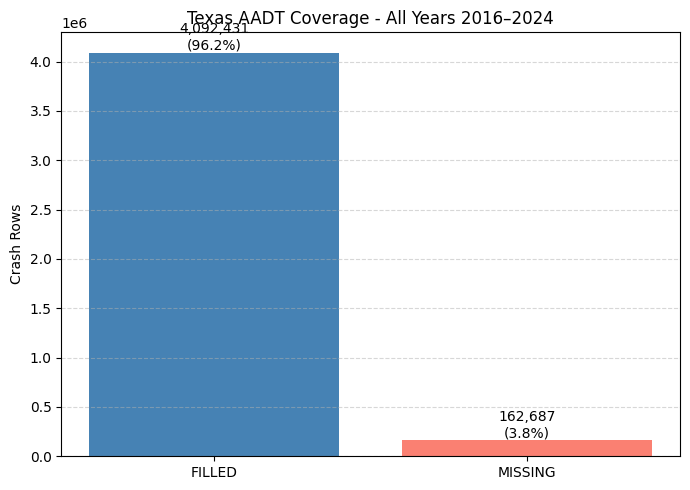

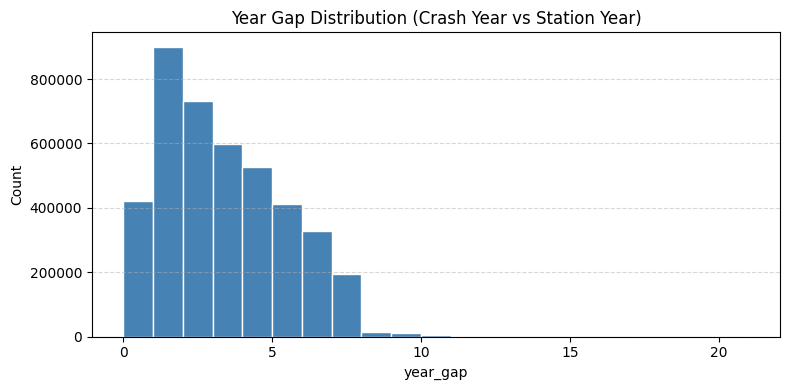

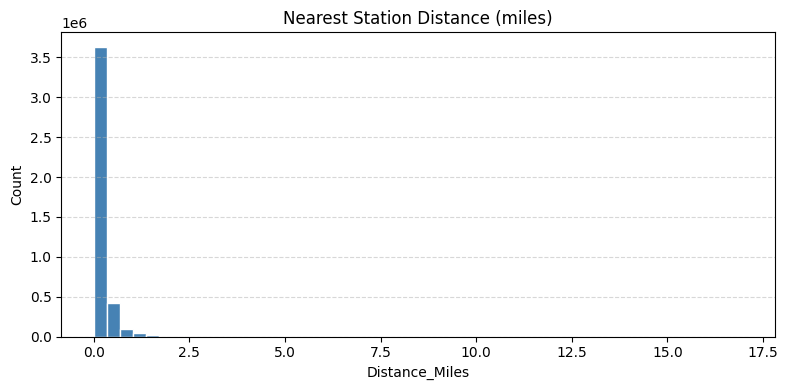

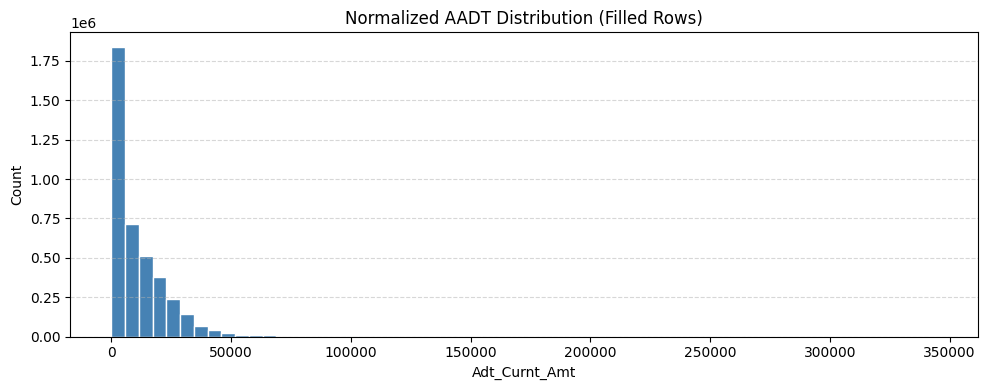

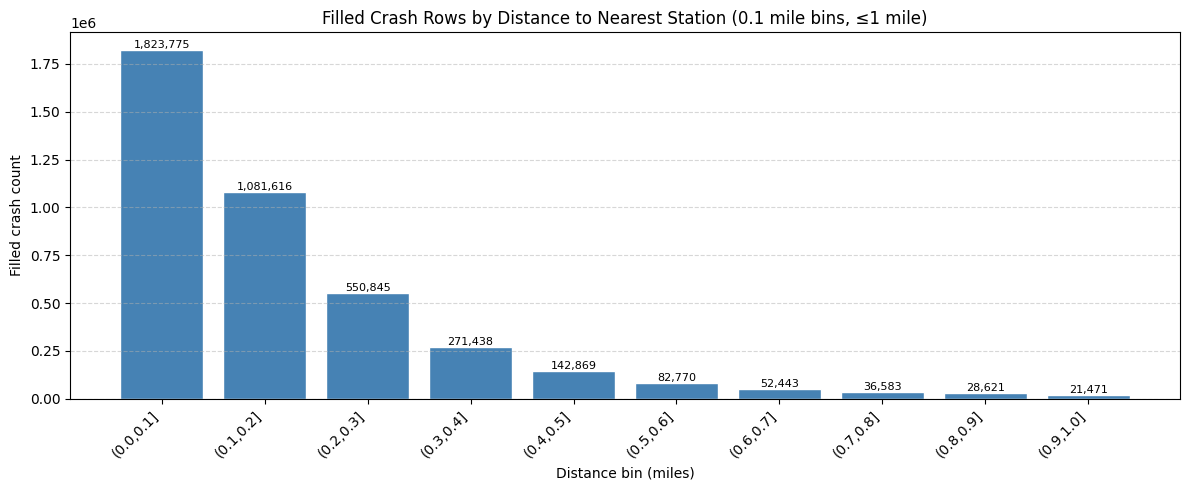

dist_bin
(-0.001, 0.1]    1823775
(0.1, 0.2]       1081616
(0.2, 0.3]        550845
(0.3, 0.4]        271438
(0.4, 0.5]        142869
(0.5, 0.6]         82770
(0.6, 0.7]         52443
(0.7, 0.8]         36583
(0.8, 0.9]         28621
(0.9, 1.0]         21471
Name: count, dtype: int64

Total filled within 1 mile : 4,092,431
Average distance (miles)   : 0.1702
Median  distance (miles)   : 0.1154
Min / Max (miles)          : 0.0001 / 1.0000

Total rows all years    : 4,255,118
Filled all years        : 4,092,431
Missing all years       : 162,687
Overall fill rate       : 96.18%


In [41]:
# ── ACTION 09: QA Visualizations (5 plots — same as Arizona) ─────────────────
# all years combined for better sample size in charts — can also do per-year if desired

df_all = pd.concat(all_outputs, ignore_index=True)

filled  = df_all["Adt_Curnt_Amt"].notna().sum()
missing = df_all["Adt_Curnt_Amt"].isna().sum()
total   = len(df_all)

# Plot 1 — Filled vs Missing bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(["FILLED", "MISSING"], [filled, missing], color=["steelblue", "salmon"])
plt.title("Texas AADT Coverage - All Years 2016–2024")
plt.ylabel("Crash Rows")
plt.grid(axis="y", linestyle="--", alpha=0.5)
for b in bars:
    v   = int(b.get_height())
    pct = v / total * 100
    plt.text(b.get_x() + b.get_width() / 2, v,
             f"{v:,}\n({pct:.1f}%)", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot1_filled_vs_missing.png"), dpi=150)
plt.show()

# Plot 2 — Year-gap histogram
yg = pd.to_numeric(df_all["year_gap"], errors="coerce").dropna()
plt.figure(figsize=(8, 4))
plt.hist(yg, bins=range(0, int(yg.max()) + 2), color="steelblue", edgecolor="white")
plt.title("Year Gap Distribution (Crash Year vs Station Year)")
plt.xlabel("year_gap")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot2_year_gap.png"), dpi=150)
plt.show()

# Plot 3 — Distance-to-station histogram
dist = pd.to_numeric(df_all["Distance_Miles"], errors="coerce").dropna()
plt.figure(figsize=(8, 4))
plt.hist(dist, bins=50, color="steelblue", edgecolor="white")
plt.title("Nearest Station Distance (miles)")
plt.xlabel("Distance_Miles")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot3_distance_hist.png"), dpi=150)
plt.show()

# Plot 4 — Normalized AADT distribution
aadt = pd.to_numeric(df_all["Adt_Curnt_Amt"], errors="coerce").dropna()
plt.figure(figsize=(10, 4))
plt.hist(aadt, bins=60, color="steelblue", edgecolor="white")
plt.title("Normalized AADT Distribution (Filled Rows)")
plt.xlabel("Adt_Curnt_Amt")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot4_aadt_dist.png"), dpi=150)
plt.show()

# Plot 5 — Distance-bin chart (0.1-mile bins within 1 mile)
df_1mi = df_all[
    df_all["Adt_Curnt_Amt"].notna() &
    df_all["Distance_Miles"].notna() &
    (df_all["Distance_Miles"] <= 1.0) &
    (df_all["Distance_Miles"] >= 0.0)
].copy()

bin_edges = np.round(np.arange(0.0, 1.0 + 0.1, 0.1), 2)
df_1mi["dist_bin"] = pd.cut(
    df_1mi["Distance_Miles"],
    bins=bin_edges,
    include_lowest=True,
    right=True
)
bin_counts = df_1mi["dist_bin"].value_counts().sort_index()
labels = [f"({bin_edges[i]:.1f},{bin_edges[i+1]:.1f}]" for i in range(len(bin_edges) - 1)]

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, bin_counts.values, color="steelblue", edgecolor="white")
plt.title("Filled Crash Rows by Distance to Nearest Station (0.1 mile bins, ≤1 mile)")
plt.xlabel("Distance bin (miles)")
plt.ylabel("Filled crash count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
for b in bars:
    v = int(b.get_height())
    plt.text(b.get_x() + b.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot5_distance_bins.png"), dpi=150)
plt.show()

print(bin_counts)
print(f"\nTotal filled within 1 mile : {bin_counts.sum():,}")
print(f"Average distance (miles)   : {df_1mi['Distance_Miles'].mean():.4f}")
print(f"Median  distance (miles)   : {df_1mi['Distance_Miles'].median():.4f}")
print(f"Min / Max (miles)          : "
      f"{df_1mi['Distance_Miles'].min():.4f} / {df_1mi['Distance_Miles'].max():.4f}")

print(f"\nTotal rows all years    : {total:,}")
print(f"Filled all years        : {filled:,}")
print(f"Missing all years       : {missing:,}")
print(f"Overall fill rate       : {filled / total * 100:.2f}%")

In [42]:
summary_rows = []

for df in all_outputs:
    yr = int(df["Crash_Year"].iloc[0])
    total = len(df)
    filled = df["Adt_Curnt_Amt"].notna().sum()
    missing = total - filled

    summary_rows.append({
        "year": yr,
        "total_rows": total,
        "filled_rows": filled,
        "missing_rows": missing,
        "fill_pct": round(filled / total * 100, 2),
        "unique_stations_matched": df["Nearest_Station_LocationId"].nunique()
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)

print("\nTOTAL:")
print("Rows:", summary_df["total_rows"].sum())
print("Filled:", summary_df["filled_rows"].sum())
print("Missing:", summary_df["missing_rows"].sum())
print("Overall fill %:", round(summary_df["filled_rows"].sum() / summary_df["total_rows"].sum() * 100, 2))

   year  total_rows  filled_rows  missing_rows  fill_pct  \
0  2016      497189       478562         18627     96.25   
1  2017      484825       466324         18501     96.18   
2  2018      490927       471780         19147     96.10   
3  2019      504885       485867         19018     96.23   
4  2020      423987       407145         16842     96.03   
5  2021      491698       472915         18783     96.18   
6  2022      496021       477165         18856     96.20   
7  2023      377107       362885         14222     96.23   
8  2024      488479       469788         18691     96.17   

   unique_stations_matched  
0                    63473  
1                    63595  
2                    63969  
3                    64038  
4                    62511  
5                    63755  
6                    63607  
7                    59136  
8                    63777  

TOTAL:
Rows: 4255118
Filled: 4092431
Missing: 162687
Overall fill %: 96.18


In [43]:
# ── Sample Output Table + Save ────────────────────────────────────────────────

# Find the crash ID column
possible_id_cols = [
    "Crash_ID", "CrashId", "CrashID",
    "IncidentId", "Incident_ID", "IncidentID",
    "ReportNumber", "CaseNumber", "Case_ID"
]
crash_id_col = next((c for c in possible_id_cols if c in df_final.columns), None)
if crash_id_col is None:
    df_final["crash_id"] = df_final.index.astype(int)
    crash_id_col = "crash_id"

sample_cols = {
    crash_id_col                 : "Crash_ID",
    "Crash_Year"                 : "crash_year",
    "Latitude"                   : "Latitude",
    "Longitude"                  : "Longitude",
    "ZIP_Code"                   : "ZIP_Code",
    "Nearest_Station_LocationId" : "station_id",
    "Station_Count"              : "raw_aadt",
    "Station_Year"               : "Station_Year",
    "VMT_Multiplier"             : "VMT_Multiplier",
    "Adt_Curnt_Amt"              : "Adt_Curnt_Amt",
    "year_gap"                   : "year_gap",
    "Distance_Miles"             : "Distance_Miles",
    "aadt_match_type"            : "aadt_match_type",
}

use_cols = [c for c in sample_cols if c in df_final.columns]

sample = (
    df_final[df_final["Adt_Curnt_Amt"].notna()]
    [use_cols]
    .rename(columns=sample_cols)
    .sample(n=min(10, df_final["Adt_Curnt_Amt"].notna().sum()), random_state=42)
    .reset_index(drop=True)
)

# Display in notebook
print("Sample Output Table (10 rows):")
print(sample.to_string())

# Save to CSV
sample_path = os.path.join(OUT_DIR, "sample_output_table.csv")
sample.to_csv(sample_path, index=False)
print(f"\n✅ Sample table saved → {sample_path}")

# ── Required Output Column Check ─────────────────────────────────────────────
print("\nRequired output column check:")
required_output_cols = [
    "Crash_ID" if "Crash_ID" in df_final.columns else crash_id_col,
    "Latitude",
    "Longitude",
    "ZIP_Code",
    "Adt_Curnt_Amt",
    "Distance_Miles",
    "Station_Year",
    "year_gap",
    "aadt_match_type",
    "VMT_Multiplier",
]

all_present = True
for col in required_output_cols:
    status = "✅" if col in df_final.columns else "❌ MISSING"
    if "❌" in status:
        all_present = False
    print(f"  {status}  {col}")

if all_present:
    print("\n✅ All required columns present — pipeline complete!")
else:
    print("\n⚠️  Some required columns are missing — check above.")

# Save full column list to a text file for reference
cols_path = os.path.join(OUT_DIR, "output_columns.txt")
with open(cols_path, "w") as f:
    f.write("All columns in df_final:\n")
    for col in df_final.columns.tolist():
        f.write(f"  {col}\n")
print(f"✅ Full column list saved → {cols_path}")

Sample Output Table (10 rows):
   Crash_ID  crash_year   Latitude  Longitude  ZIP_Code station_id  raw_aadt  Station_Year  VMT_Multiplier  Adt_Curnt_Amt  year_gap  Distance_Miles           aadt_match_type
0  20248573        2024  29.845718 -95.392991     77076    102U331   21710.0          2021        1.079243   23430.357644         3        0.052422  NEAREST_STATION_VMT_NORM
1  20194600        2024  27.276416 -98.134391     78355    126H110   12407.0          2023        1.020896   12666.250746         1        0.797881  NEAREST_STATION_VMT_NORM
2  20553186        2024  30.161046 -97.686352     78719   227UR577     451.0          2020        1.183846     533.914615         4        0.209342  NEAREST_STATION_VMT_NORM
3  20531205        2024  32.917260 -96.521597     75089   57HP6960   15615.0          2019        1.067268   16665.384882         5        0.222066  NEAREST_STATION_VMT_NORM
4  20476915        2024  29.544726 -95.217726     77546       85U2     997.0          2022        1

In [44]:
for df in all_outputs:

    crash_year = int(df["Crash_Year"].iloc[0])

    required_cols = [
        "Crash_ID",
        "Latitude",
        "Longitude",
        "ZIP_Code",
        "Adt_Curnt_Amt",
        "Distance_Miles",
        "Station_Year",
        "year_gap",
        "aadt_match_type",
        "VMT_Multiplier"
    ]

    if "Crash_ID" not in df.columns:
        df["Crash_ID"] = df.index

    df_final_export = df.copy()

    for c in required_cols:
        if c not in df_final_export.columns:
            df_final_export[c] = np.nan

    df_final_export = df_final_export[required_cols]

    out_path = os.path.join(OUT_DIR, f"Cleaned_Data_Final_{crash_year}.csv")
    df_final_export.to_csv(out_path, index=False)

    print(f"Saved {crash_year} → {len(df_final_export):,} rows")

Saved 2016 → 497,189 rows
Saved 2017 → 484,825 rows
Saved 2018 → 490,927 rows
Saved 2019 → 504,885 rows
Saved 2020 → 423,987 rows
Saved 2021 → 491,698 rows
Saved 2022 → 496,021 rows
Saved 2023 → 377,107 rows
Saved 2024 → 488,479 rows


In [45]:
year_counts = {}
min_date = None
max_date = None

for chunk in pd.read_csv(
    MASTER_CRASH_PATH,
    skiprows=4,
    usecols=["Crash_Date"],
    on_bad_lines="skip",
    chunksize=100_000,
    low_memory=False
):
    chunk["Crash_Date"] = pd.to_datetime(
        chunk["Crash_Date"],
        errors="coerce"
    )

    counts = chunk["Crash_Date"].dt.year.value_counts(dropna=False)

    for year, count in counts.items():
        year_counts[year] = year_counts.get(year, 0) + count

    chunk_min = chunk["Crash_Date"].min()
    chunk_max = chunk["Crash_Date"].max()

    if pd.notna(chunk_min):
        min_date = chunk_min if min_date is None else min(min_date, chunk_min)
    if pd.notna(chunk_max):
        max_date = chunk_max if max_date is None else max(max_date, chunk_max)

print("Year counts:")
print(pd.Series(year_counts).sort_index())

print("\nMin date:", min_date)
print("Max date:", max_date)

Year counts:
2016    1097926
2017     537497
2018     544176
2019     561412
2020     472050
2021     547288
2022     551766
2023     420714
2024     549428
dtype: int64

Min date: 2016-01-01 00:00:00
Max date: 2024-12-31 00:00:00
